In [16]:
import torch
import torch.nn as nn

In [17]:
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np

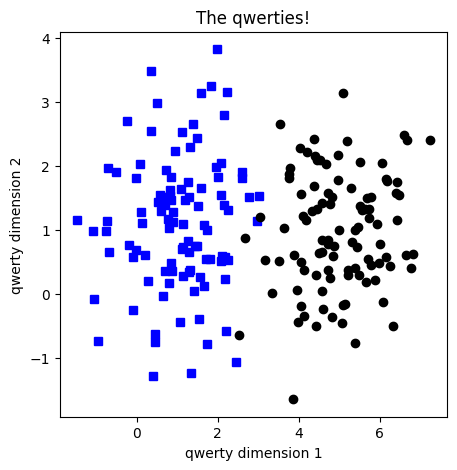

In [18]:
nPerClust = 100
blur = 1

A = [1,1]
B = [5,1]

a = [ A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur ]

labels_np = np.vstack( (np.zeros((nPerClust,1)), np.ones((nPerClust,1)) ) )

data_np = np.hstack( (a,b) ).T

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0], 0], data[np.where(labels==0)[0], 1], 'bs')
plt.plot(data[np.where(labels==1)[0], 0], data[np.where(labels==1)[0], 1], 'ko')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [19]:
print(type(data_np))
print(np.shape(data_np))
print(' ')

print(type(data))
print(np.shape(data))

<class 'numpy.ndarray'>
(200, 2)
 
<class 'torch.Tensor'>
torch.Size([200, 2])


In [30]:
class ANNClass(nn.Module):
    # Objects | layers
    def __init__(self):
        super().__init__()

        self.input = nn.Linear(2,1)
    
        self.output = nn.Linear(1,1)

    # Actions | Operations
    def forward(self, x):

        x = self.input(x)
        
        x = F.relu(x)

        x = self.output(x)
        x = torch.sigmoid(x)

        return x

ANNclassify = ANNClass()

In [31]:
'''
ANNclassify = nn.Sequential(
    nn.Linear(2,1),
    nn.ReLU(),
    nn.Linear(1,1),
    nn.Sigmoid(),
)
'''

'\nANNclassify = nn.Sequential(\n    nn.Linear(2,1),\n    nn.ReLU(),\n    nn.Linear(1,1),\n    nn.Sigmoid(),\n)\n'

In [32]:
learningRate = .01

lossfun = nn.BCELoss()

optimizer = torch.optim.SGD(ANNclassify.parameters(), lr=learningRate)

In [33]:
numepochs = 1000
losses = torch.zeros(numepochs)

for epochi in range(numepochs):

    yHat = ANNclassify(data)

    loss = lossfun(yHat, labels)
    losses[epochi] = loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()